***

* [射电干涉孔径合成基础](../0_Introduction/0_introduction.ipynb)
* [术语表](../0_Introduction/1_glossary.ipynb)
* [第1章：利用干涉阵开展射电科学](1_0_introduction.ipynb)
    * 上一节：[1.1 基础天体物理简述](1_1_a_brief_introduction_to_basic_astrophysics.ipynb)
    * 下一节：[1.3. 辐射传输](1_3_radiative_transport.ipynb)

***


导入标准模块:


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML 
HTML('../style/course.css') # 应用通用 CSS

导入本节所需的专用模块:

In [2]:
from IPython.display import Image

## 1.2 电磁辐射与天文测量量

在射电干涉测量中，真正被天线接收、被相关器处理、被成像算法重建的，并不是一个模糊的“光”，而是一组可以严格定义的电磁场和辐射测量量。若不先把这些量分清楚，后面几章里出现的可见度、波束、亮温、通量密度和校准量就会混在一起。因此，本节的目标并不是把电磁理论从头重讲一遍，而是建立一套足以支撑后续全书的语言框架。

本节将依次建立这套语言。首先从麦克斯韦方程说明射电信号为什么可以视为传播中的电磁波；随后讨论极化如何由横向电场分量的幅度和相位决定；接着区分光度、通量密度和比强度这些容易混淆的辐射量；最后说明射电图像中的 Jy/beam 与亮温之间如何联系起来。这样处理之后，后面关于可见度、波束、成像单位和校准量的讨论就会有明确的物理落点。


### 1.2.1 射电信号首先是电磁波

对射电天文学而言，把辐射当作经典电磁波来处理通常已经足够。原因并不是光子概念不重要，而是在大多数射电观测场景中，接收机面对的是大量电磁波叠加后的电场信号，后端电子学直接处理的也是与电场振幅相关的电压时间序列。因此，在进入辐射机制和干涉相关之前，先把射电信号理解为随时间和空间传播的电磁波，是最自然的起点。

这里先考虑最简单但最重要的情形：信号在远离源和天线的自由空间中传播，局部区域内没有自由电荷和自由电流。这并不意味着真实宇宙中没有等离子体、尘埃和磁场，而是说在讨论一小段传播路径、并忽略介质响应时，电磁场本身满足真空中的麦克斯韦方程：

$$\nabla\cdot \mathbf{E}=0, \qquad \nabla\cdot \mathbf{B}=0$$

$$\nabla\times \mathbf{E}=-\frac{\partial \mathbf{B}}{\partial t}, \qquad \nabla\times \mathbf{B}=\frac{1}{c^2}\frac{\partial \mathbf{E}}{\partial t}.$$

这组方程本身已经包含了电磁波的传播性质。为了看清这一点，对法拉第定律两边取旋度：

$$\nabla\times(\nabla\times\mathbf{E})=-\frac{\partial}{\partial t}(\nabla\times\mathbf{B}).$$

右边利用安培-麦克斯韦方程，左边利用矢量恒等式 $\nabla\times(\nabla\times\mathbf{E})=\nabla(\nabla\cdot\mathbf{E})-\nabla^2\mathbf{E}$。由于真空中 $\nabla\cdot\mathbf{E}=0$，就得到

$$-\nabla^2\mathbf{E}=-\frac{1}{c^2}\frac{\partial^2\mathbf{E}}{\partial t^2},$$

也就是

$$\nabla^2\mathbf{E}-\frac{1}{c^2}\frac{\partial^2\mathbf{E}}{\partial t^2}=0.$$

同样的步骤也可用于 $\mathbf{B}$，得到

$$\nabla^2\mathbf{B}-\frac{1}{c^2}\frac{\partial^2\mathbf{B}}{\partial t^2}=0.$$

这就是电场和磁场的波动方程。它的物理含义是：电场的时间变化会产生磁场的空间旋度，磁场的时间变化又会产生电场的空间旋度，二者相互维持并以速度 $c$ 向前传播。

对单色平面波，更常用的写法是

$$\mathbf{E}(\mathbf{r},t)=\Re\left\{\mathbf{E}_0\exp[i(\omega t-\mathbf{k}\cdot\mathbf{r}+\phi_0)]\right\}.$$

把这个形式代入波动方程，会得到色散关系 $\omega=c|\mathbf{k}|$，也就是 $|\mathbf{k}|=2\pi/\lambda=\omega/c$。这里 $\omega=2\pi\nu$ 是角频率，$\mathbf{k}$ 是波矢，$\phi_0$ 是初相位。麦克斯韦方程还要求 $\mathbf{k}\cdot\mathbf{E}_0=0$，说明电场垂直于传播方向；磁场也垂直于传播方向，并满足 $\mathbf{B}_0=(1/\omega)\mathbf{k}\times\mathbf{E}_0$。因此，一个射电平面波不仅有频率和振幅，也有传播方向、相位和横向矢量结构。

这些量中，相位对干涉测量尤其关键。两面天线接收同一个远处平面波时，由于位置不同，会采样到不同的 $\mathbf{k}\cdot\mathbf{r}$ 项；这正是几何相位、基线和可见度概念的起点。


在射电数据处理中，复数表示法尤其重要。它不是数学上的小技巧，而是非常自然的工程语言。因为只要把信号写成复数形式，相位延迟、频率滤波、相关和傅里叶变换都可以被统一而紧凑地表达。后面第 4 章的可见度、第 7 章的 Jones 链和第 8 章的定标，本质上都建立在这种复数电场表示之上。


### 1.2.2 极化并不是附加信息，而是电场本身的一部分

上一小节已经看到，平面电磁波的电场垂直于传播方向。因此，对于沿 $z$ 方向传播的波，真正独立的电场自由度只有横向的两个分量。把公共的传播因子提出去，电场可以写成

$$\mathbf{E}_\perp(t,z)=\Re\left\{\begin{pmatrix} E_{0x}e^{i\phi_x} \\ E_{0y}e^{i\phi_y} \end{pmatrix}e^{i(kz-\omega t)}\right\}.$$

括号中的二维复向量称为 Jones 向量。它不是人为加上的记号，而是横向电场本身的紧凑表达。两个分量的幅度 $E_{0x}$、$E_{0y}$ 决定电场在两个正交方向上的强弱，相位差

$$\Delta\phi=\phi_y-\phi_x$$

决定电场矢量随时间扫出的轨迹形状。

若两个分量相位相同或相差 $\pi$，电场矢量始终沿某一固定直线振荡，对应线偏振。若两个分量幅度相等且相位差为 $\pm\pi/2$，电场端点会画出圆，对应圆偏振。一般情况下，幅度不等或相位差取任意值，电场端点会画出椭圆，对应椭圆偏振。由此可见，极化并不是总强度之外额外附带的装饰信息，而是电场矢量随时间演化的几何形态。


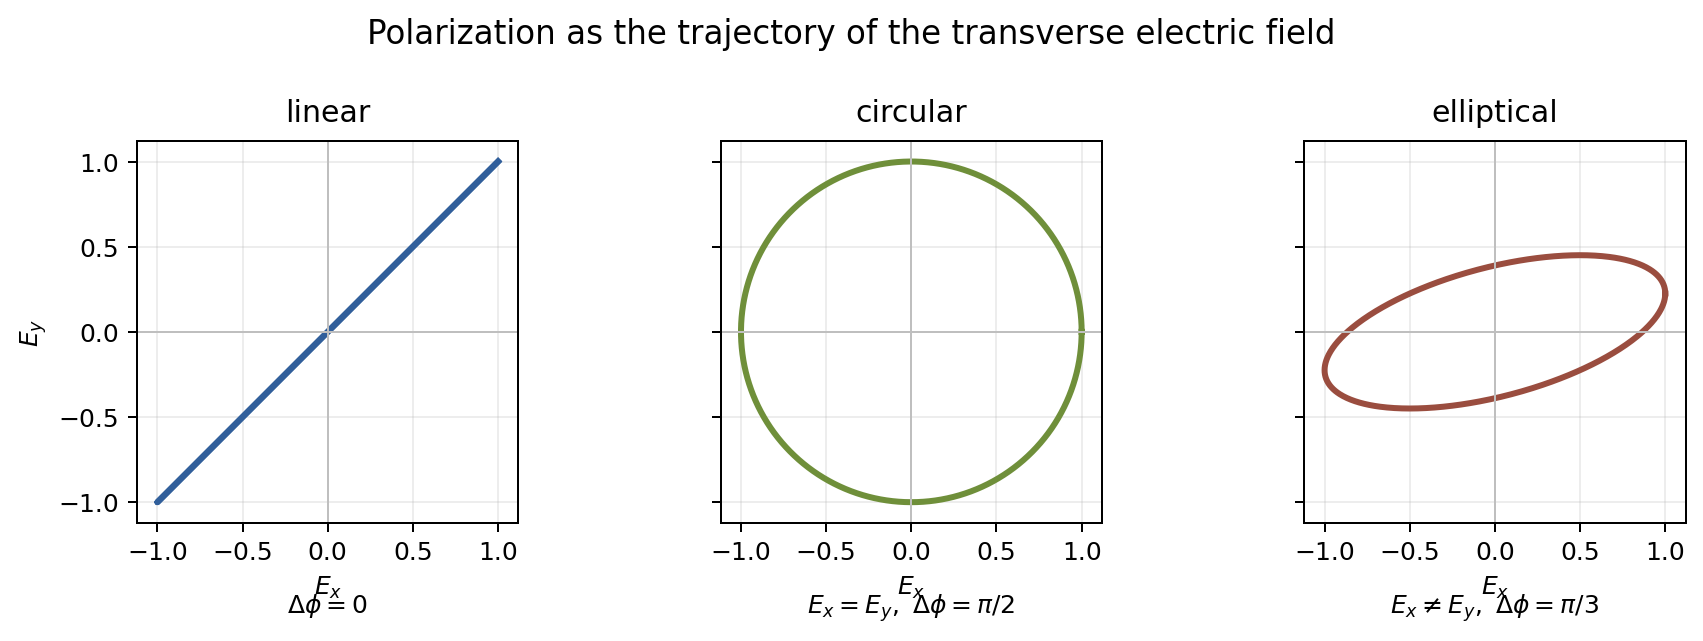

In [3]:
Image(filename='figures/polarization_states.png', width=900)


**图 1.2.1**：不同幅度比和相位差对应不同极化状态。左图相位差为零，电场沿固定直线振荡；中图幅度相等且相位差为 $\pi/2$，电场端点形成圆；右图为一般椭圆偏振。真实射电源常是许多波包和许多微小发射区域的叠加，因此观测上更常用统计量来描述极化状态。

实际射电观测通常不会直接保存某一个时刻的电场轨迹，而是通过相关和时间平均得到 Stokes 参数。若用复电场分量表示，并暂时忽略整体校准因子，一组常用定义为

$$I=\langle |E_x|^2+|E_y|^2\rangle,$$

$$Q=\langle |E_x|^2-|E_y|^2\rangle,$$

$$U=2\,\mathrm{Re}\langle E_xE_y^*\rangle,$$

$$V=2\,\mathrm{Im}\langle E_xE_y^*\rangle.$$

这里的尖括号表示对许多波周期或有限带宽内的统计平均。$I$ 描述总强度，$Q$ 和 $U$ 描述线偏振的大小和方向，$V$ 描述圆偏振。不同文献和软件对 $V$ 的符号约定可能不同，但核心思想不变：极化信息来自两个正交电场分量的自相关和互相关。

这一点与仪器直接相关。单个馈源通常只对某一极化分量敏感，因此观测系统天然具有极化选择性；两个极化通道之间的增益、相位和泄漏误差，会直接进入后续校准问题；干涉相关也不只是测总强度，而是测不同极化通道之间的相关矩阵，从而恢复 Stokes 参数。这些内容将在 [7.1 节](../7_Observing_Systems/7_1_jones_notation.ipynb) 和极化相关章节中系统展开。


### 1.2.3 从源的发光能力到望远镜收到的信号

天体物理里最本征的辐射量之一是**光度** $L$，它表示源单位时间辐射出的总功率；若按频率分辨，则得到**谱光度** $L_\nu$：

$$L=\int L_\nu\,d\nu$$

但望远镜并不能直接包围一个天体去测它的总辐射功率。我们实际位于距离源很远的位置，只能截获其中极小的一部分。因此，观测上更直接的量是**通量密度** $S_\nu$，即单位面积、单位频率接收到的功率。对于各向同性发射的点源，有

$$S_\nu = \frac{L_\nu}{4\pi D^2}$$

其中 $D$ 是距离。这个关系很简单，但它提醒我们：光度是源本身的性质，而通量密度是观测者位置处的量，会随着距离按 $D^{-2}$ 衰减。


射电天文学最常用的通量密度单位是詹斯基（Jy）：

$$1\,\mathrm{Jy}=10^{-26}\,\mathrm{W\,m^{-2}\,Hz^{-1}}$$

之所以要引入这样一个专门单位，是因为天体射电信号通常非常微弱。对点源来说，通量密度已经是相当有用的观测量；但一旦源被空间分辨开，仅知道“总通量有多少”就不够了，因为我们还想知道这些辐射在天空上是如何分布的。这时就必须引入方向相关的量。


### 1.2.4 为什么成像真正关心的是比强度

若要描述某个方向上的辐射场，仅使用总通量或点源通量是不够的。我们需要知道：某个微小立体角方向上，有多少功率穿过某个微小面积元。这就引出了**比强度**（specific intensity，也常称亮度）$I_\nu$。它定义为：


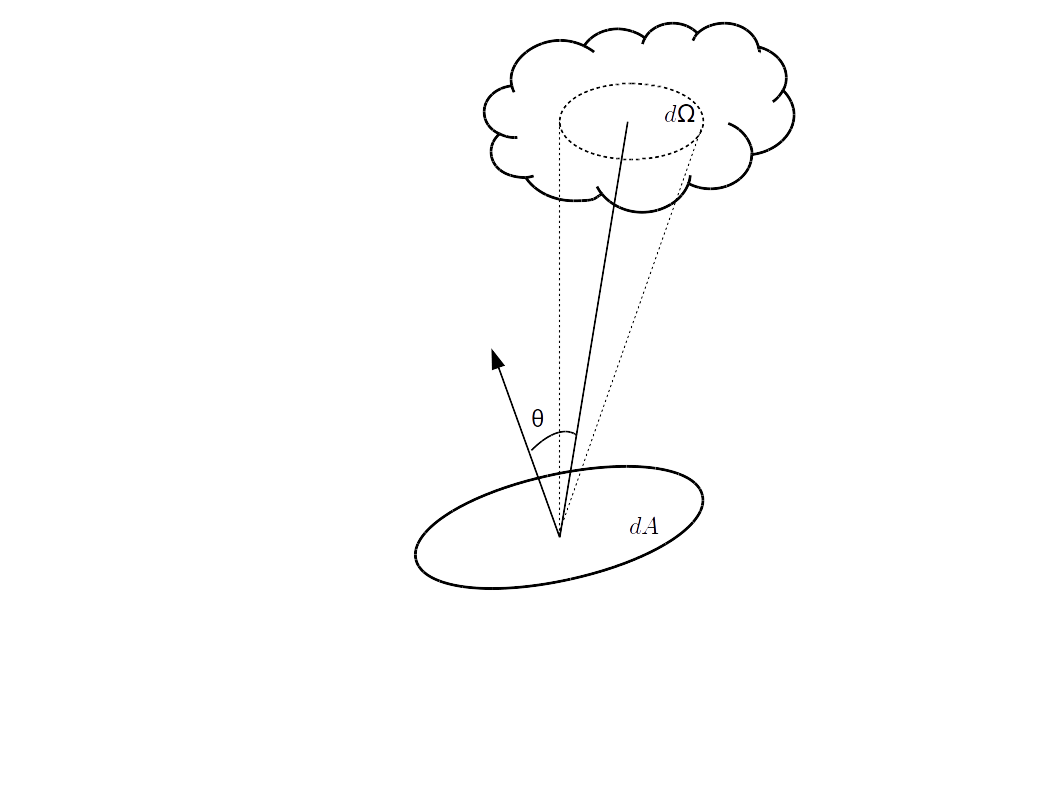

In [3]:
Image(filename='figures/solid_angle_1.png', width=500)

$$
\begin{aligned}
dP &= I_\nu(\theta,\phi)\,dA_{\rm eff}\,d\nu\,d\Omega \\
   &= I_\nu(\theta,\phi)\,\cos\theta\,dA\,d\nu\,d\Omega
\end{aligned}
$$

这里 $d\Omega$ 是天空方向上的微小立体角，$dA_{\rm eff}=\cos\theta\,dA$ 是沿该方向投影后的有效面积。与通量密度不同，比强度显式保留了方向信息，因此它才适合作为成像和辐射传输的基本变量。


一个对整个射电天文学都极其重要的事实是：如果沿射线路径没有发生新的发射和吸收，那么比强度不会因为距离变远而自动衰减。这一点看起来似乎和通量密度按距离平方衰减相矛盾，但二者描述的并不是同一个量。通量密度下降，是因为同一束辐射在更远处摊到更大的立体角范围和面积关系上；而比强度作为“每单位立体角、每单位投影面积”的量，恰好把这种几何扩张抵消掉了。


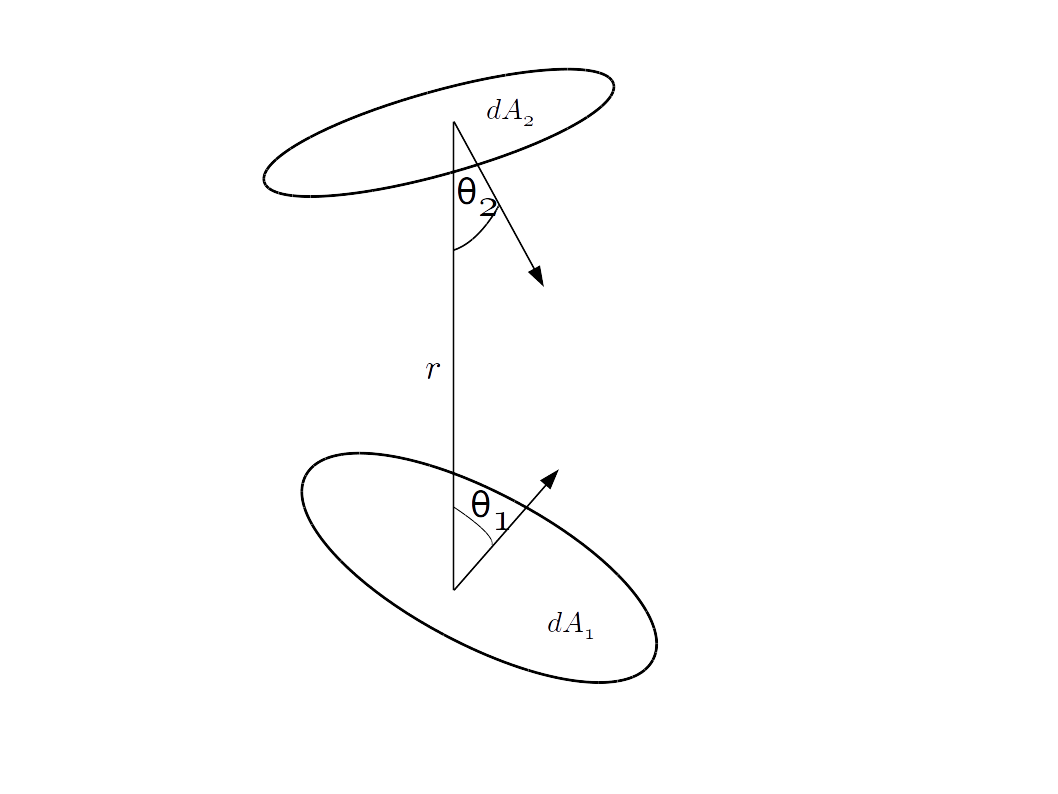

In [5]:
Image(filename='figures/solid_angle_2.png', width=500)

利用上图的两个面积元，可以更直观地看到这一点：

$$d\Omega_1 = \frac{\cos\theta_2\,dA_2}{r^2}, \qquad d\Omega_2 = \frac{\cos\theta_1\,dA_1}{r^2}$$

若沿传播路径没有发射和吸收，则两处通过的功率相同，于是可推出对应方向上的 $I_\nu$ 保持不变。正因为如此，比强度才会成为辐射传输方程中的核心量，而不是总光度或通量密度。


### 1.2.5 通量、比强度、波束与图像单位之间的关系

一旦知道天空亮度分布 $I_\nu(\theta,\phi)$，就可以通过对源在天空所张立体角积分来得到总通量密度：

$$S_\nu = \int I_\nu(\theta,\phi)\,d\Omega$$

这条关系直接区分了未分辨点源和已分辨展源。对未分辨点源来说，源在图像中只占据一个分辨元，常常可以用总通量密度 $S_\nu$ 描述它有多亮；对已分辨展源来说，仅知道总通量已经不够，因为同样的总通量可以集中在一个很小区域，也可以铺展在很大的天空面积上。后者必须回到 $I_\nu(\theta,\phi)$，也就是天空亮度分布本身。

实际射电图像中，人们常看到的单位不是 ${\rm Jy\,sr^{-1}}$，而是 `${\rm Jy\,beam^{-1}}`。这是因为图像像素并不直接对应理想的无穷小立体角，而是对应望远镜或合成波束对天空卷积后的结果。也就是说，`${\rm Jy\,beam^{-1}}` 反映的是“在一个分辨元内测得的通量密度”。这与后面成像章节中的主波束、脏波束和恢复波束都会直接相关。


下面这张图把这些量放在同一条链上。它强调的是物理含义的转换：从源本身的谱光度，到观测者接收到的通量密度，再到天空上每个方向的比强度；成像之后，有限波束把亮度分布平滑成 Jy/beam，最后在瑞利-金斯近似下又可以转写成亮温。


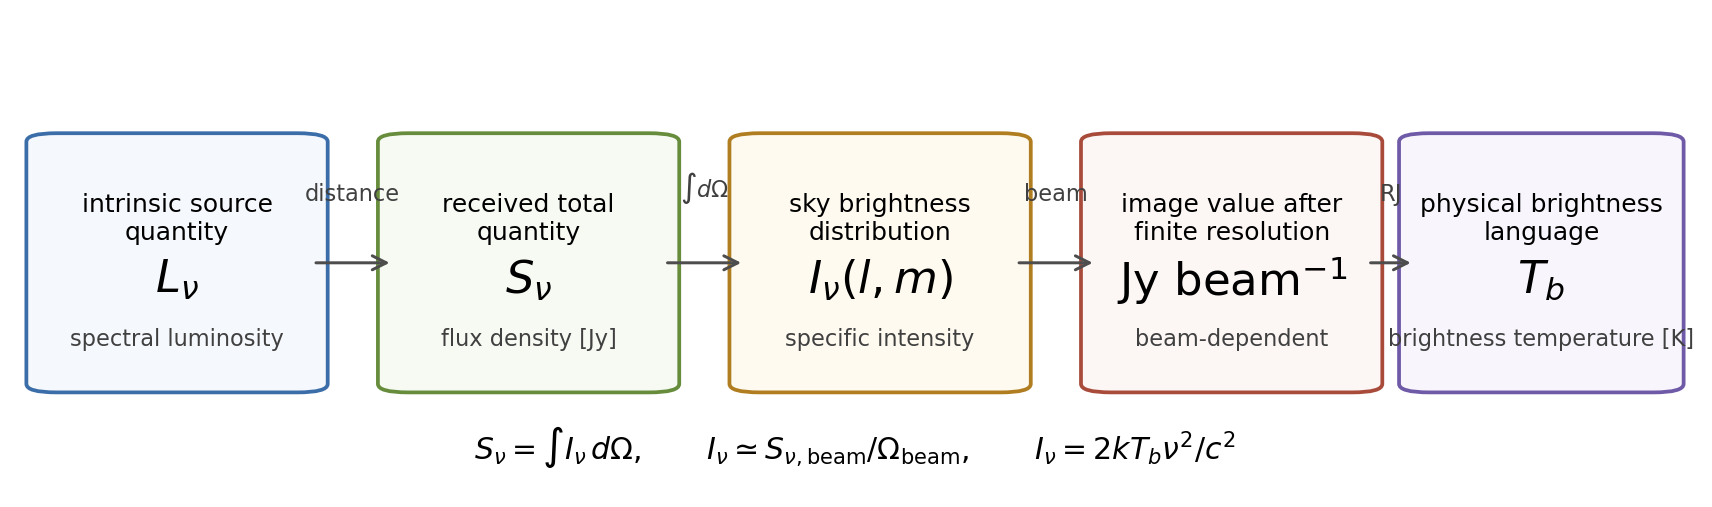

In [4]:
Image(filename='figures/radiometric_quantity_map.png', width=950)


**图 1.2.2**：射电观测中几个常见辐射量之间的关系。$L_\nu$ 是源本身的发光能力，$S_\nu$ 是观测者接收到的总通量密度，$I_\nu$ 描述天空上每个方向的亮度分布；图像中的 `${\rm Jy\,beam^{-1}}` 是 $I_\nu$ 经过有限波束平滑后的常用表达，而亮温 $T_b$ 则是在射电极限下对亮度的温度化表达。


若恢复波束可以近似为二维高斯，主轴和次轴半高全宽分别为 $\theta_{\rm maj}$ 与 $\theta_{\rm min}$，则波束立体角近似为

<a id='science:eq:02_beam_solid_angle'></a>
$$\Omega_{\rm beam} \simeq \frac{\pi\,\theta_{\rm maj}\theta_{\rm min}}{4\ln 2}.$$

如果图像峰值是 $S_{\nu,\rm beam}$，单位为 Jy/beam，那么对应的平均比强度近似为

$$I_\nu \simeq \frac{S_{\nu,\rm beam}}{\Omega_{\rm beam}}.$$

再用瑞利-金斯近似 $I_\nu=2kT_b\nu^2/c^2$，就得到射电成像中极常用的换算式

<a id='science:eq:02_jybeam_to_tb'></a>
$$T_b\,[\mathrm{K}] \simeq 1.222\times 10^6\,\frac{S_{\nu,\rm beam}\,[\mathrm{Jy\,beam^{-1}}]}{\nu_{\rm GHz}^2\,\theta_{\rm maj}['']\,\theta_{\rm min}['']}.$$

这条公式的物理含义很直接：同样的 Jy/beam，在更高频率或更大波束下对应更低亮温；在更小波束下则意味着更高的单位立体角亮度。


In [ ]:
Image(filename='figures/brightness_temperature_conversion.png', width=720)


**图 1.2.3**：同样是 1 Jy/beam，不同频率和不同波束面积对应的亮温可以相差很多。读射电图像时，不能只看 Jy/beam 的数值大小，还必须同时看频率和恢复波束。这个判断在比较不同阵列、不同构型或不同频段的图像时尤其重要。


这里还需要提前建立一个非常重要的观念：**干涉阵并不直接测光度，也不直接测总通量，而是测与天空亮度分布相关的空间频率分量。** 因此，若不先理解 $I_\nu$ 这一量，后面的可见度方程就会显得非常抽象。反过来说，一旦接受“干涉阵成像本质上是在重建天空亮度分布”，第 4 章和第 5 章里的许多公式就会顺理成章。


### 1.2.6 与后续章节的联系

本节引入的量会在后面以不同面貌反复出现。电场的复数表示会进入相关器输出和可见度定义；极化分量会进入 Jones 链、Stokes 参数和偏振成像；比强度会进入辐射传输方程、黑体辐射和亮温定义；通量密度和 `${\rm Jy\,beam^{-1}}` 则会出现在成像结果、源测量和科学量估计中。

这些量之间的区分看似基础，却直接影响后续推理。$L_\nu$ 关心源本身的发光能力，$S_\nu$ 关心观测者收到的总信号，$I_\nu$ 关心天空上每个方向的亮度分布，Jy/beam 又把有限角分辨率引入图像单位。只有把这些层次分清楚，后面才不会把“源本身有多亮”“我们在地球上收到多少信号”“图像上一个像素值代表什么”混为一谈。


### 1.2.7 本节应记住什么

射电信号在大多数观测问题中可以自然地视为经典电磁波。麦克斯韦方程给出了电场和磁场的波动方程，也说明电磁波具有横向矢量结构；复数表示法则把振幅和相位放在同一个表达式中，为相关、傅里叶分析和可见度定义提供了自然语言。极化不是总强度之外的附属修饰，而是横向电场两个分量之间幅度和相位关系的表现。

在辐射测量量方面，光度 $L_\nu$ 描述源本身的发光能力，通量密度 $S_\nu$ 描述观测者处接收到的单位面积功率，比强度 $I_\nu$ 则保留方向信息，并且在无发射无吸收时沿射线保持不变。干涉阵真正关心的是天空亮度分布及其空间频率分量，因此 $I_\nu$ 是后续章节最重要的辐射量之一。下一节将进入辐射传输，讨论当介质中的吸收和发射不能忽略时，比强度如何沿传播路径发生系统性变化。


***

* 下一节：[1.3. 辐射传输](1_3_radiative_transport.ipynb)
